MACHINE LEARNING

PROGETTO 4

Sviluppare una pipeline completa di Machine Learning per la Regressione, applicata al dataset multivariato Diabetes.

Effettuare il confronto e l’ottimizzazione dei seguenti modelli predittivi per stimare un valore target numerico continuo:
    • Regressione Lineare
    • Decision Tree
    • Regressione Ridge
    • Regressione Lasso
    • K-Nearest Neighbor
    • Support Vector Machine

1 Data Exploration & Preprocessing

    1. Caricamento e Analisi del dataset e fornire un’analisi descrittiva iniziale(i.e. df.describe())
    2. Visualizzazione tramite strumenti grafici (istogrammi, boxplot, scatter matrix) per comprendere la distribuzione delle feature e identificarepotenziali correlazioni o outlier
    3. Preparazione dei dati in set di Training e Test utilizzando la funzionetrain test split

2 Confronto e Selezione Iniziale dei Modelli

    1. Implementare e confrontare almeno quattro algoritmi di Regressione standard
    2. Utilizzare la K-Fold Cross-Validation per valutare le prestazioni medie diciascun modello sul set di training
    3. Basare il confronto sulla metrica NMSE (Negative Mean Squared Error)

3 Hyperparameters Tuning

    1. Grid Search per ottimizzare un iperparametro cruciale
    2. Valutazione Finale per calcolare e riportare le metriche finali (MSE, R2) sul set di Test utilizzando il modello ottimizzato

4 Analisi delle Performance

    1. Learning Curves per il modello ottimizzato, valutando bias e varianza,e commentando la tendenza del modello a overfitting o underfitting

5 Visualizzazione con Data Reduction

    1. PCA per ridurre lo spazio delle feature a due dimensioni (PC1 & PC2)
    2. Plot della Regressione per visualizzare il piano di regressione del modello ottimizzato nello spazio bidimensionale

In [3]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA
from sklearn.datasets import load_diabetes
from pandas.plotting import scatter_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import learning_curve,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score,KFold,train_test_split
from sklearn.preprocessing import StandardScaler

1 Data Exploration & Preprocessing

    1. Caricamento e Analisi del dataset e fornire un’analisi descrittiva iniziale(i.e. df.describe())

In [47]:
data=load_diabetes()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name="target")

df=X.copy()
df["target"]=y

display(df)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


ANALISI DELLE FEATURES

In [48]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

Elenco features **(recuperato in internet)**
Sex variabile binaria
age	età
sex	sesso
bmi	indice massa corporea
bp	pressione sanguigna
s1	colesterolo totale
s2	LDL
s3	HDL
s4	rapporto colesterolo
s5	trigliceridi
s6	glicemia

il database contiene 442 pazienti, 10 features ed un target numerico per prevedere la progressione della malattia ad 1 anno.
Il target è una variabile continua, quindi non è un problema di classificazione ma di regressione

In [49]:
print(f"Describe:\n{df.describe()}")

Describe:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.7619

Le features hanno una media attorno allo zero.
Le features hanno una deviazione standard attorno allo zero (0.0467).
Per tutte le features min e max sono attorno allo zero.
Suggerisce dati già standarizzati.
(il database diabetes non è un database reale ma 'giocattolo' di sklearn)


In [51]:
print(f"Info:\n{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
Info:
None


Il database non ha valori nulli. Ci sono 442 righe (pazienti) ogni dato è un float64. L'utilizzo della memoria è limitato

ANALISI DEL TARGET

In [52]:
df['target'].describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

mean=152
50%=140
Il target è sbilanciato verso destra, ci sono alcuni valori alti che alzano la media.
std=77
Se confrondo std (77) con mean (152) ho una variabilità del 50% suggerendo una forte dispersione. Confermato dai valori estermi min (25) e max (346)

In [53]:
iqr = df['target'].quantile(0.75) - df['target'].quantile(0.25)
print(f"IQR:\t{iqr}")

lower = df['target'].quantile(0.25) - 1.5 * iqr
upper = df['target'].quantile(0.75) + 1.5 * iqr

outliers = df[(df['target'] < lower) | (df['target'] > upper)]
print(f"Outliers:\n{outliers}")

IQR:	124.5
Outliers:
Empty DataFrame
Columns: [age, sex, bmi, bp, s1, s2, s3, s4, s5, s6, target]
Index: []


Il dataset risulta 'pulito': niente null, features già standarizzate, no outlier secondo IQR

   2. Visualizzazione tramite strumenti grafici (istogrammi, boxplot, scatter matrix) per comprendere la distribuzione delle feature e identificare potenziali correlazioni o outlier

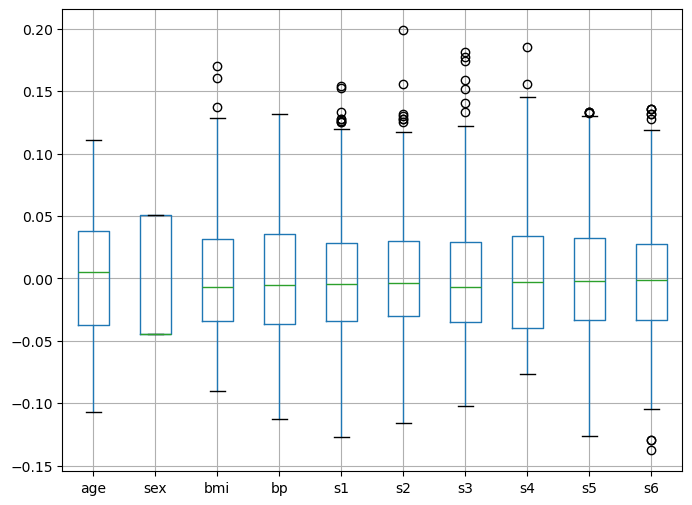

In [10]:
df_features=df.drop(columns=["target"])
df_features.boxplot(figsize=(8,6),grid=True)
plt.show()
# ho tolto target perchè il boxplot risultava schiacciato verso lo zero a causa dei valori molto più grandi del target rispetto alle features.

il boxplot conferma quanto già detto, tutte le features sono scalate ed hanno una media attorno allo zero, anche il range è simile tra le varie features.
Compaiono dei valori outlier, comunque non estermi (tutti i valori sono attorno allo zero), suggerendo che gli outlier non siano errori ma valori che fanno parte delle rilevazioni.

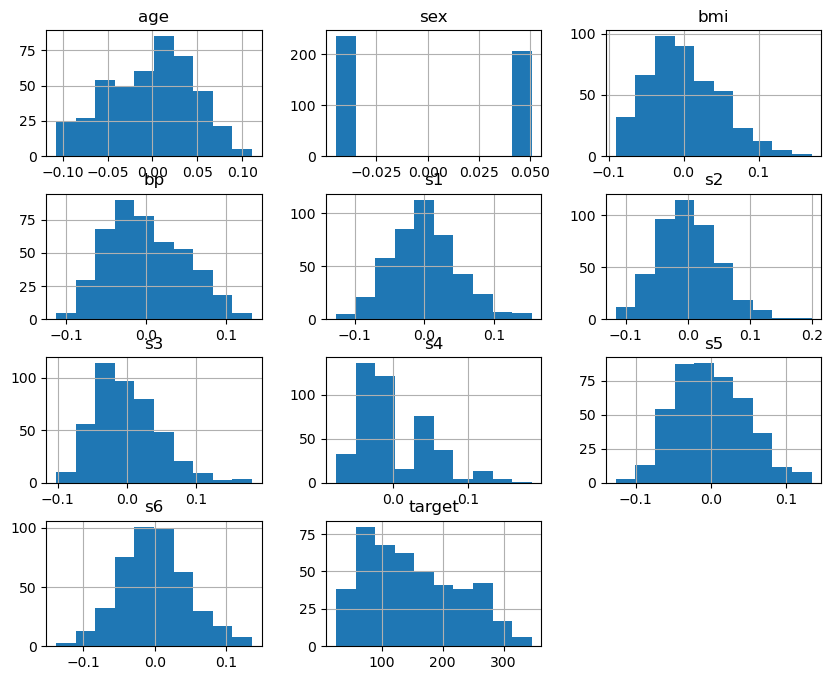

In [11]:
df.hist(figsize=(10,8))
plt.show()

Quasi tutte le features hanno una forma gaussiana. 
La curva di S4 (rapporto tra colesterolo buono e cattivo) sembra diversa rispetto alle altre forme (a più punte), non è perfettamente gaussiana, potrebbe confermare che il suo valore dipende da altre features.

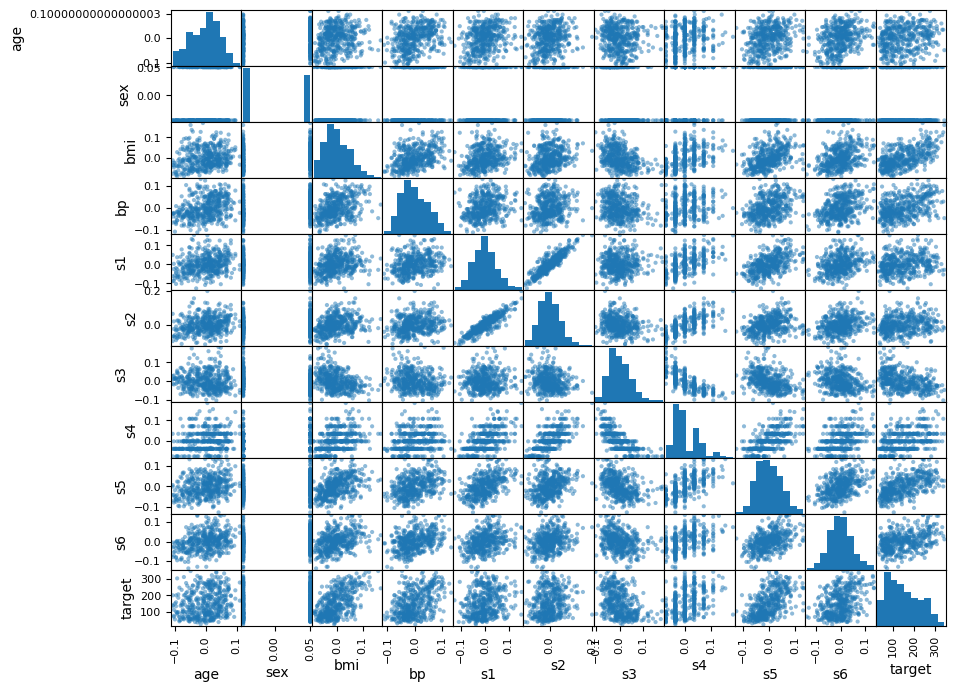

In [12]:
scatter_matrix(df,figsize=(10,8))
plt.show()

In [13]:
print(df['s4'].nunique())

66


Il target evidenzia relazioni prevalentemente lineari positive con la maggior parte delle features, esclusa S3 lineare negative. Relazione lineare positiva evidente con bmi e S5. Cob bp, S1 e S2 relazione debole. Con age e S6, dove è presente una nube larga la relazione sembra molto debole. Con sex non è presente relazione. S4 sembra una variabile discreta, non confermato da unique, quindi molti dati si concentrano su valori simili, potrebbe essere ridondante.

La relazione tra S1 e S2 è lineare e molto forte (lineare positiva), suggerendo features fortemente correlate tra loro, forse ridondanza (colesterolo totale vs LDL)
La relazione tra S3 e S4 p lineare negativa, quando uno sale l'altro scende
S4 sembra formata da delle linee suggerendo un variabile discreta, in realtà concentra i suoi dati su 66 valori, pertanto è da considerarsi continua, alcuni valori sono più frequenti di altri.

    3. Preparazione dei dati in set di Training e Test utilizzando la funzionetrain test split

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

2 Confronto e Selezione Iniziale dei Modelli

In [15]:
models = [
    ("Linear", LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("KNN", KNeighborsRegressor()),
    ("SVR", SVR()),
    ("Tree", DecisionTreeRegressor())
]

    1. Implementare e confrontare almeno quattro algoritmi di Regressione standard

In [16]:
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}\n\tMSE: {mse:.4f}\tR2: {r2:.4f}")

Linear
	MSE: 2900.1936	R2: 0.4526
Ridge
	MSE: 3077.4159	R2: 0.4192
Lasso
	MSE: 3403.5757	R2: 0.3576
KNN
	MSE: 3019.0755	R2: 0.4302
SVR
	MSE: 4333.2860	R2: 0.1821
Tree
	MSE: 5147.3708	R2: 0.0285


Con modelli standard, senza ottimizzazione degli iperparametri, MSE più basso e R2 più alto con Linear Regresssion. Il peggiore è Decision Tree con capacità predittiva quasi nulla 0.0458.
Indica una struttura linerare del problema, la regolarizzazione di Ridge e Lasso, in questo caso, penalizza con il modello standard senza fare test sugli iperparametri.
Ridge spesso migliore quando si ha multicollinearità, e qui sembra ci sia, pertanto merita un approfondimento.

In [17]:
for a in [0.01, 0.1, 1, 10, 100]:
    model = Ridge(alpha=a)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Ridge\n\talpha={a}\tMSE: {mse:.4f}\tR2: {r2:.4f}")

Ridge
	alpha=0.01	MSE: 2882.2902	R2: 0.4560
Ridge
	alpha=0.1	MSE: 2856.4869	R2: 0.4609
Ridge
	alpha=1	MSE: 3077.4159	R2: 0.4192
Ridge
	alpha=10	MSE: 4443.9526	R2: 0.1612
Ridge
	alpha=100	MSE: 5233.6637	R2: 0.0122


Ridge con alpha=0.01 ottiene dati leggermete migliori dei valori MSE e R2 del modello Linear Regressor. R2 con alpha=0.01 riesce a spiegare il 45.6% di variabilità, con alpha maggiori peggiora la situazione degradando le performance. La capacità predittiva limitata, possibile problema non completamente lineare. Non sempre è possibile migliorare il modello, a volte dato dai limiti dei dati, è necessario migliorare le features.

    2. Utilizzare la K-Fold Cross-Validation per valutare le prestazioni medie di ciascun modello sul set di training

    3. Basare il confronto sulla metrica NMSE (Negative Mean Squared Error)

In [18]:
model_grids = {
    "Linear": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10]}),
    "Lasso": (Lasso(), {"alpha": [0.01, 0.1, 1, 10]}),
    "KNN": (KNeighborsRegressor(), {"n_neighbors": [3,5,7,9]}),
    "SVR": (SVR(), {"C": [0.1,1,10],"epsilon": [0.1,0.2],"gamma": ["scale", "auto"]}),
    "Tree": (DecisionTreeRegressor(), {"max_depth": [None, 3,5,10],"min_samples_split": [2,5,10]})
}

In [19]:
K=5
kf=KFold(n_splits=K,shuffle=True,random_state=42)

In [ ]:
results = []

for name, (model, params) in model_grids.items():
    grid = GridSearchCV(model,params,cv=kf,scoring={"r2": "r2", "mse": "neg_mean_squared_error"},n_jobs=-1,refit="r2")
    grid.fit(X_train, y_train)

    best_index = grid.best_index_

    r2 = grid.cv_results_["mean_test_r2"][best_index]
    mse = -grid.cv_results_["mean_test_mse"][best_index]
    
    results.append((name, r2, mse, grid.best_params_))

    print(f"{name}\n\tMSE: {mse:.4f}\tBest R2: {r2:.4f}\n\tBest params: {grid.best_params_}")

Linear
	MSE: 3074.1421	Best R2: 0.4804
	Best params: {}
Ridge
	MSE: 3075.7956	Best R2: 0.4802
	Best params: {'alpha': 0.01}
Lasso
	MSE: 3070.5169	Best R2: 0.4810
	Best params: {'alpha': 0.01}
KNN
	MSE: 3538.3115	Best R2: 0.4026
	Best params: {'n_neighbors': 9}
SVR
	MSE: 3369.2153	Best R2: 0.4348
	Best params: {'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}
Tree
	MSE: 4169.7032	Best R2: 0.2880
	Best params: {'max_depth': 3, 'min_samples_split': 5}


Lasso, Linear e Ridge hanno quasi tutti lo stesso valore R2 (leggermente migliore per Lasso), circa il 48% della variabilità dei dati non è spiegata, non è poco
Lasso risulta il migliore modello per R2. Questo suggerisce relazioni lineari.

In [28]:
model_best = None
r2_best = -999  # valore molto basso iniziale

for result in results:
    name = result[0]
    r2 = result[1]
    mse = result[2]
    params = result[3]

    if r2 > r2_best:
        r2_best = r2
        model_best = result

# stampa risultato
print(f"Miglior modello in assoluto per R2:\n\tModello: {model_best[0]}\n\tR2: {model_best[1]:.4f}\n\tMSE: {model_best[2]:.4f}")
print(f"Best params: {model_best[3]}")

Miglior modello in assoluto per R2:
	Modello: Lasso
	R2: 0.4810
	MSE: 3070.5169
Best params: {'alpha': 0.01}


4 Analisi delle Performance

    1. Learning Curves per il modello ottimizzato, valutando bias e varianza,e commentando la tendenza del modello a overfitting o underfitting

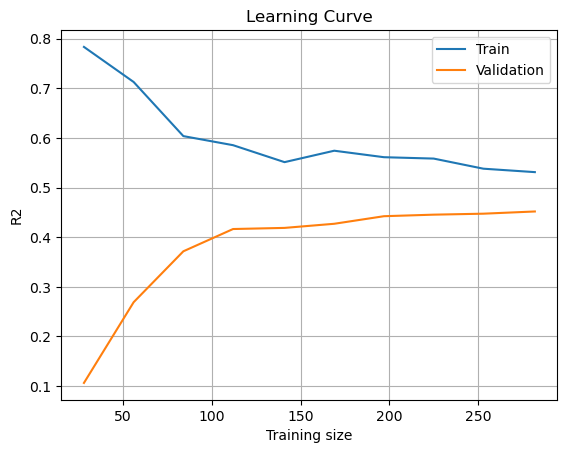

In [30]:
modello=Lasso(alpha=0.01)

train_sizes, train_scores, test_scores = learning_curve(
    modello,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, test_mean, label="Validation")

plt.xlabel("Training size")
plt.ylabel("R2")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.show()

Il modello mostra inizialmente overfitting che si ridure aumentando i dati. All'aumentare dei dati, le prestazioni del validation migliorano, mentre quelle del training diminuisono. Le curve tendono a stabilizzarzi attorno a 200 senza convergere, suggerendo la presenza di un overfitting residuo. Il tutto suggerisce che il limite non sia la quantità dei dati ma le feature disponibili

5 Visualizzazione con Data Reduction

    1. PCA per ridurre lo spazio delle feature a due dimensioni (PC1 & PC2)
    2. Plot della Regressione per visualizzare il piano di regressione del modello ottimizzato nello spazio bidimensionale

In [ ]:
#PCA
pca=PCA(n_components=2)
X_train_pca=pca.fit_transform(X_train)
X_test_pca=pca.transform(X_test)

In [ ]:
#modello ottimizzato
lasso_pca = Lasso(alpha=0.01)
lasso_pca.fit(X_train_pca, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [54]:
def plot_regression(ax,X,labels,model, title):
   h = 0.02
   x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
   y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
   xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
   Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
   Z = Z.reshape(xx.shape)
   ax.contourf(xx, yy, Z, alpha=0.3)
   ax.scatter(X[:, 0], X[:, 1], c=labels, s=50, edgecolor='k')
   ax.set_title(title)
   ax.set_xlabel("PC 1")
   ax.set_ylabel("PC 2")

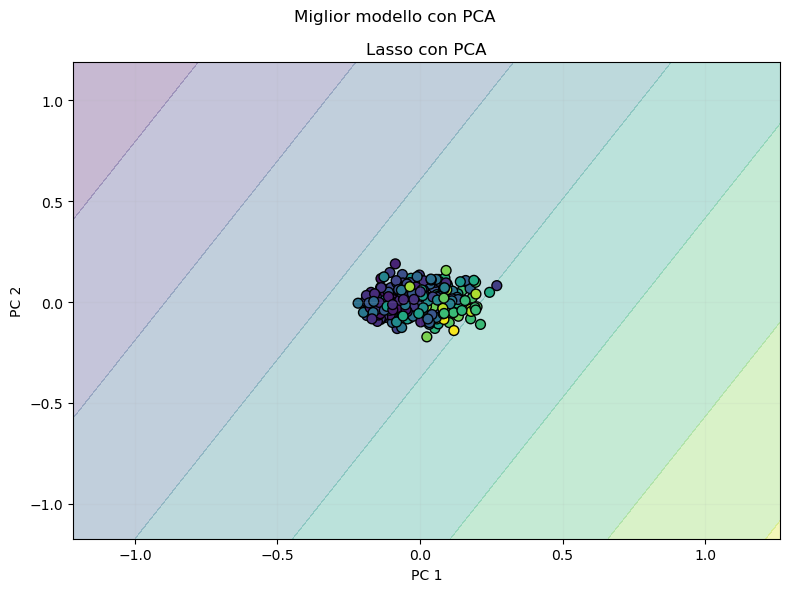

In [55]:
fig,axes=plt.subplots(1,1,figsize=(8,6))
plot_regression(axes,X_train_pca,y_train,lasso_pca,"Lasso con PCA")
#plot_regression(axes[1],X_train_pca,y_train,kmeans_best_pca,"K-means Tuned")
plt.suptitle("Miglior modello con PCA")
plt.tight_layout()
plt.grid(True,alpha=0.1)
plt.show()

Dataset piccolo, feature già standarizzate, target continuo, relazioni principali lineari, lasso leggermente migliore dopo tunning, 